In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from adaptive_smc.save_and_read_and_postprocess import acf


PKLs = []
PKL_titles = []
DIR = "./uncoupled_ar_rw_proposal/output_dim5_mean0/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR + file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [2]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'AR',
'build_build_gaussian_rw_proposal' : 'RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"Uncoupled AR/RW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}

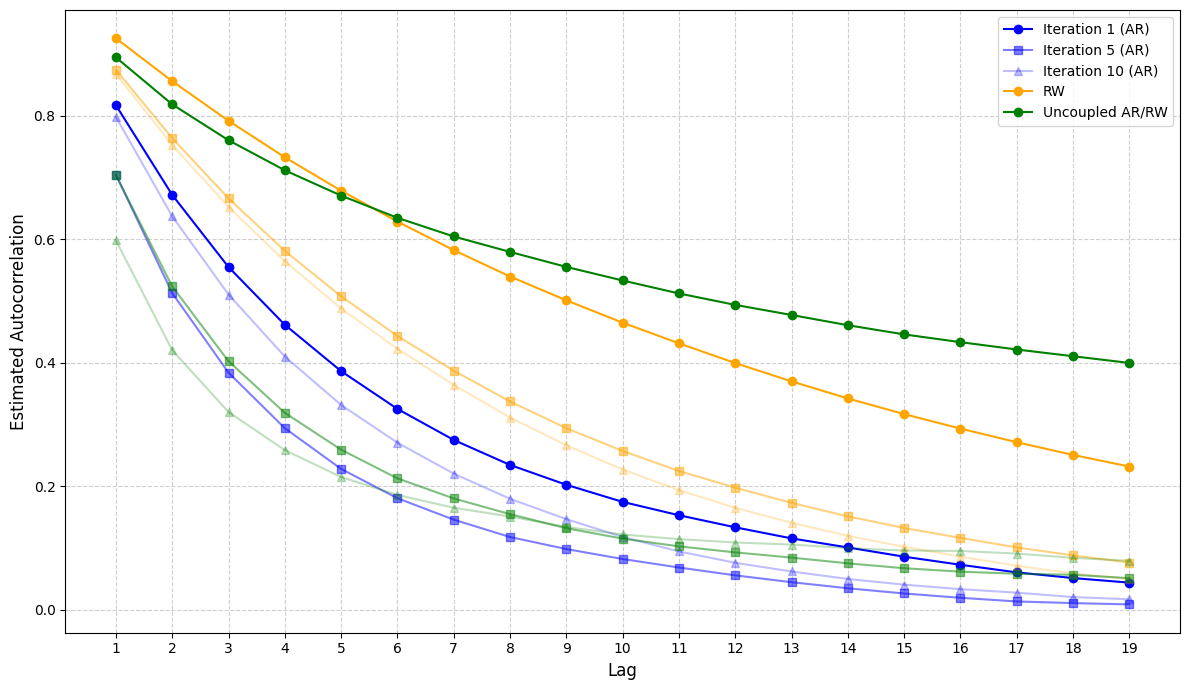

In [141]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["blue", "orange", "green"]
alphas = [1., 0.5, 0.25]
component_idx = 2

plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    for idx in idx_proposal[proposal][:1]:
        acfs = acf(PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis])[..., 0, 0]
        for idx_it, it in enumerate([1, 5, 10]):
            marker = ['o', 's', '^'][idx_it % 3]  # Use different markers for clarity
            plt.plot(np.arange(1, 20), acfs[:, it], 
                     marker=marker, 
                     label=f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it==0 else None,
                     color=colors[p_idx], 
                     alpha=alphas[idx_it],
                     linewidth=1.5)

# Beautify plot
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Estimated Autocorrelation", fontsize=12)
#plt.title("Autocorrelation Function by Proposal and Iteration", fontsize=13)
plt.xticks(ticks=np.arange(1, 20, 1))  # Only integer x-ticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


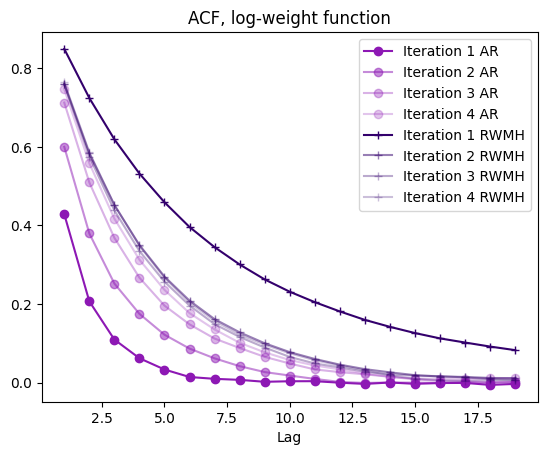

In [4]:
from adaptive_smc.problems.gaussian import create_problem

tau = jnp.sqrt(0.1)
dim = PKLs[0]['res'][0].shape[-1]
cov = jnp.eye(dim) * 1 / (1 / tau ** 2 - 1)
mean = jnp.ones(dim)

loglikelihood_fn = create_problem(dim, mean=jnp.ones(dim), scale=jnp.sqrt(1 / (1 / tau ** 2 - 1)))


def log_weight_function(dlmbda, x):
    ll = loglikelihood_fn(x)
    dlmbda = dlmbda.reshape(dlmbda.shape + (1,) * (jnp.ndim(ll) - jnp.ndim(dlmbda)))
    return dlmbda * ll


labels = ['AR', 'RWMH']

for _idx, l in enumerate([list_idx_ar, list_idx_rwmh]):
    for idx in l:
        samples = PKLs[idx]['res'][0][:,:,0]
        dlmbdas = jnp.diff(jnp.insert(PKLs[0]['res'][6], 0, 0., -1), axis=-1) # inserting 0, \lmbda_1, \lmbda_2-\lmbda1, ..., \lmbda_{T-1}-\lambda_T
        max_temp_idx = jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1]
        log_weights = jnp.expand_dims(log_weight_function(dlmbdas, samples), -1)
        acfs = acf(log_weights)[..., 0, 0]
        for it in range(1, max_temp_idx):
            if it % 1 == 0:
                plt.plot(np.arange(1, 20), acfs[:, it], marker='o' if _idx == 0 else '+',
                         label=f"Iteration {it} {labels[_idx]}", color=color_set[_idx], alpha=1 / (it),
                         )
        plt.legend()
plt.xlabel("Lag")
plt.title("ACF, log-weight function")
plt.savefig(DIR+"ACF_lw.png")

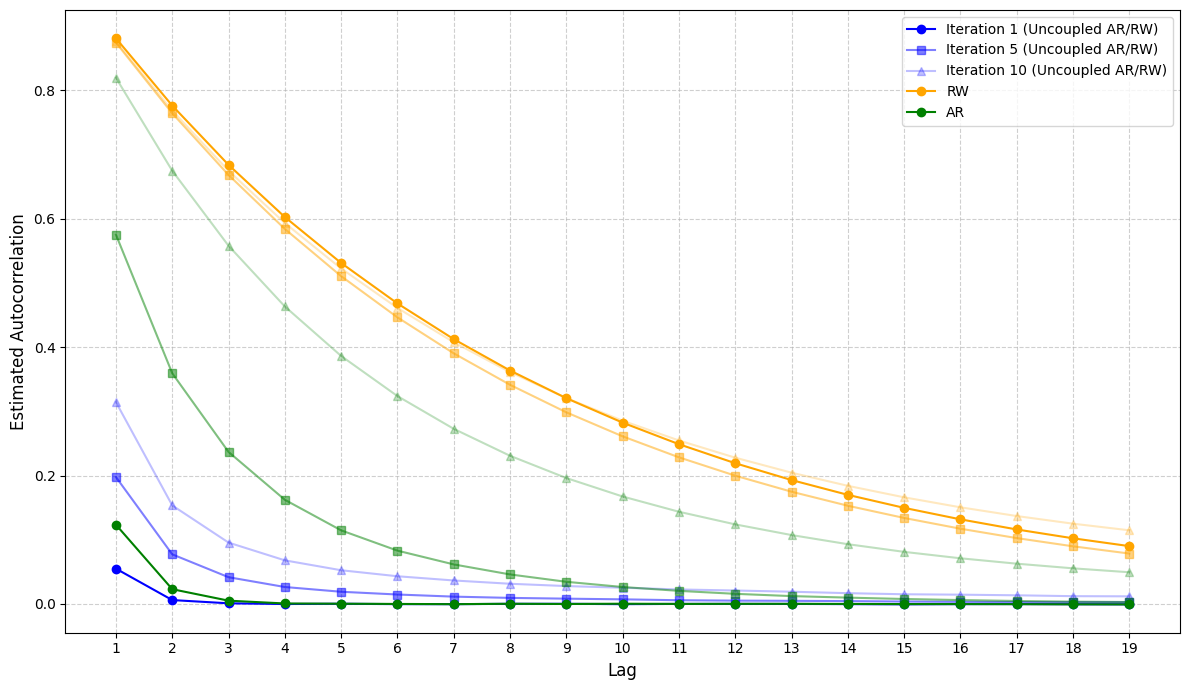

In [3]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["blue", "orange", "green"]
alphas = [1., 0.5, 0.25]
component_idx = 2

plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0)
    acfs = acf(samples)[..., 0, 0]
    for idx_it, it in enumerate([1, 5, 10]):
        marker = ['o', 's', '^'][idx_it % 3]  # Use different markers for clarity
        plt.plot(np.arange(1, 20), acfs[:, it], 
                 marker=marker, 
                 label=f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it==0 else None,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1.5)

# Beautify plot
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Estimated Autocorrelation", fontsize=12)
#plt.title("Autocorrelation Function by Proposal and Iteration", fontsize=13)
plt.xticks(ticks=np.arange(1, 20, 1))  # Only integer x-ticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


In [139]:
for proposal in idx_proposal:
    for idx in idx_proposal[proposal]:
        if PKLs[idx]['res'][0] is None:
            print(idx)
            print(PKL_titles[idx])

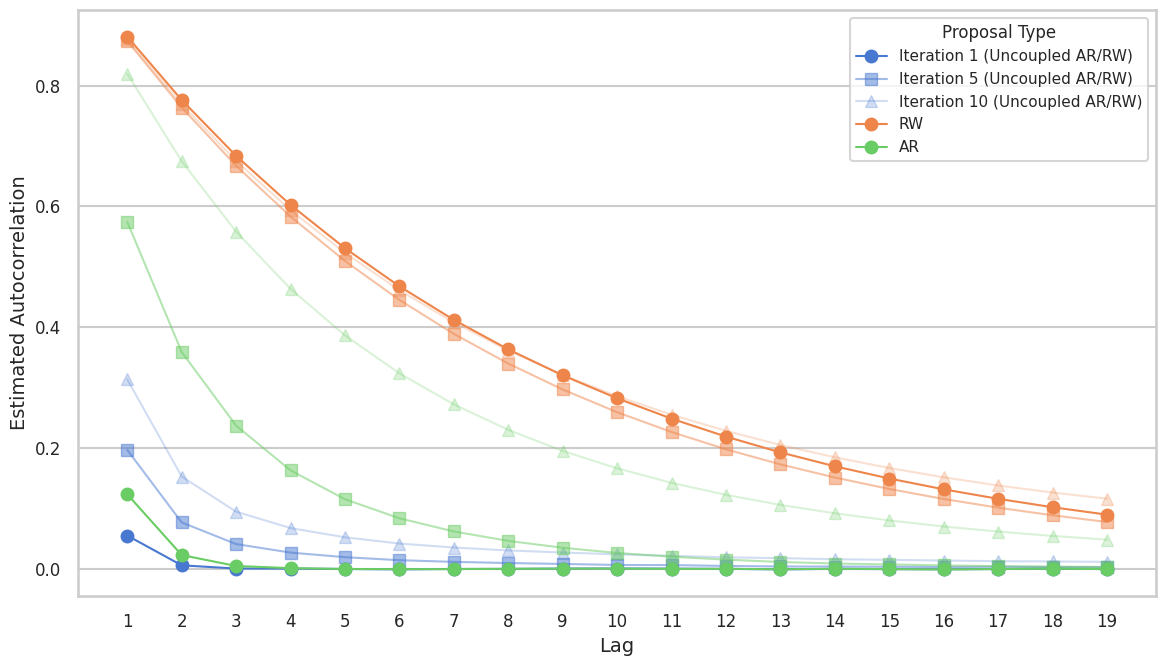

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Match Seaborn style
sns.set(style='whitegrid', context='talk', palette='muted')

colors = sns.color_palette('muted')[:3]
alphas = [1., 0.5, 0.25]
component_idx = 1

plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0)
    acfs = acf(samples)[..., 0, 0]
    for idx_it, it in enumerate([1, 5, 10]):
        marker = ['o', 's', '^'][idx_it % 3]
        label = f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it == 0 else None
        plt.plot(np.arange(1, 20), acfs[:, it], 
                 marker=marker, 
                 label=label,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1.5)

# Beautify to match boxplot
plt.xlabel("Lag", fontsize=14)
plt.ylabel("Estimated Autocorrelation", fontsize=14)
plt.xticks(ticks=np.arange(1, 20, 1), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Proposal Type', title_fontsize=12, fontsize=11, loc='upper right')

# Remove grid entirely (no vertical or horizontal lines)
plt.grid(axis='x')

plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()
